In [1]:
from colossus.cosmology import cosmology
from colossus.lss import mass_function
import matplotlib.pyplot as plt
import numpy as np

In [2]:
g3_cosmo = {'flat': True, 'H0': 70.0, 'Om0': 0.3, 'Ob0': 0.043, 'sigma8': 0.8, 'ns': 0.97}
cosmo=cosmology.setCosmology('g3_cosmo',**g3_cosmo)

In [11]:
m200 = 10**np.linspace(10,16,5000)
mfunc_0 = mass_function.massFunction(m200, 0.0, mdef='200m', model='tinker08', q_out='dndlnM')
mfunc_3 = mass_function.massFunction(m200, 0.3, mdef='200m', model='tinker08', q_out='dndlnM')

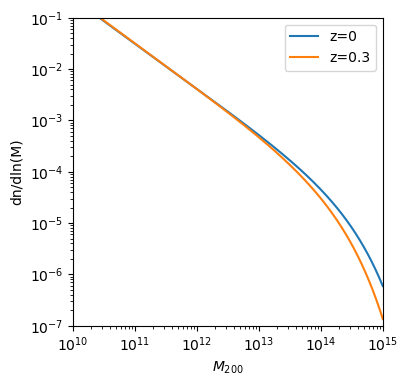

In [59]:
plt.figure(figsize=(4,4))
plt.plot(m200, mfunc_0, label='z=0')
plt.plot(m200, mfunc_3, label='z=0.3')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$M_{200}$")
plt.ylabel("dn/dln(M)")
plt.legend(loc='best')
plt.xlim(1e10,1e15)
plt.ylim(1e-7,1e-1)
plt.show()

In [56]:
dlnM = np.log(m200[1] / m200[0])
cumlMF_0 = np.cumsum(mfunc_0[::-1] * dlnM)[::-1]
cumlMF_3 = np.cumsum(mfunc_3[::-1] * dlnM)[::-1]
average = 0.5 * (cumlMF_0 + cumlMF_3)

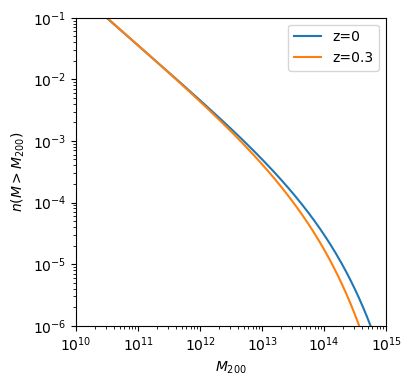

In [57]:
plt.figure(figsize=(4,4))
plt.plot(m200, cumlMF_0, label='z=0')
plt.plot(m200, cumlMF_3, label='z=0.3')
#plt.plot(m200, average, color='k', linestyle='dashed', linewidth=1, label='average')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$M_{200}$")
plt.ylabel(r"$n(M>M_{200})$")
plt.legend(loc='best')
plt.xlim(1e10,1e15)
plt.ylim(1e-6,1e-1)
plt.show()